In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

2025-04-11 12:20:58,759::INFO::settings.py::Setting loglevel to INFO
2025-04-11 12:20:58,761::INFO::settings.py::Setting stores to {}
2025-04-11 12:20:58,762::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-04-11 12:20:58,763::INFO::settings.py::Setting database.misc.create_tables to True
2025-04-11 12:20:58,765::INFO::settings.py::Setting enable_python_native_blobs to True
2025-04-11 12:20:58,766::INFO::settings.py::Setting database.host to vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com
2025-04-11 12:20:58,767::INFO::settings.py::Setting database.user to thomas
2025-04-11 12:20:58,768::INFO::settings.py::Setting database.password to thomas_mathislab
2025-04-11 12:20:58,954::INFO::connection.py::Connected thomas@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


Connecting thomas@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


2025-04-11 12:20:59,061::INFO::table.py::could not log event in table ~log
2025-04-11 12:20:59,496::INFO::table.py::could not log event in table ~log
2025-04-11 12:20:59,496::INFO::table.py::could not log event in table ~log
2025-04-11 12:21:00,198::INFO::table.py::could not log event in table ~log
2025-04-11 12:21:00,198::INFO::table.py::could not log event in table ~log
2025-04-11 12:21:00,371::INFO::table.py::could not log event in table ~log
2025-04-11 12:21:00,371::INFO::table.py::could not log event in table ~log
2025-04-11 12:21:00,738::INFO::table.py::could not log event in table ~log
2025-04-11 12:21:00,738::INFO::table.py::could not log event in table ~log
2025-04-11 12:21:01,068::INFO::table.py::could not log event in table ~log
2025-04-11 12:21:01,068::INFO::table.py::could not log event in table ~log


In [4]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc
from vr4mice.analysis import utils
from vr4mice.schema.vr4mice import Dataset

from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats

style()

save_fig_path = "notebooks/Paper_figures/Figure_output/"

In [ ]:
tolias = pd.read_pickle("big_df_contrast_tolias_new.pkl")
neil_df = pd.read_pickle("big_df_contrast_dual_niell.pkl")
mathis =  pd.read_pickle("dual_occluder.pickle")

big_df = pd.concat([tolias, neil_df, mathis]).reset_index(drop=True)
big_df, reward_table = utils.dual_occluder_inclusion_criteria(big_df, return_excluded=False)
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})
big_df = big_df [big_df.iti == 0.0].copy()
j_shaped = analysis.get_jshaped_trials(big_df, threshold_duration=5, threshold_tortuosity=3).copy()
interpolated_j_shaped = utils.interpolate_j_shaped(
    j_shaped, box_df, n_points=100
)  # 100 to run anova
data = interpolated_j_shaped

Excluded datasets:  ['31728_2025-03-05_1' '31728_2025-03-06_1' 'J729_2024-11-29_1'
 'J731_2024-12-04_1' 'J731_2024-12-06_1']


In [62]:
def mean_trajectory_time(df, index_columns = ["dataset", "mouse_name", "aperture", "trial_left_choice", "trial_length"]):
    
    mean_df = df.groupby(index_columns,as_index=False)[["x", "y"]].mean()
    mean_df [["sem_x", "sem_y"]] = df.groupby(index_columns,as_index=False)[["x","y"]].sem()[["x","y"]]
    return(mean_df)

In [133]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D  # For custom legend handles

def plot_mean_trajectory_time(df, cmap=["red", "blue"], color_by="choice", style_by="aperture"):
    """
    Plots mean trajectories with flexible assignment of colors and line styles.
    
    Parameters:
    -----------
    df : DataFrame
        Contains columns: x, y, sem_x, sem_y, aperture, trial_left_choice
    cmap : list or matplotlib colormap
        Color scheme for different choices
    color_by : str ('choice' or 'aperture')
        Which variable to represent with colors
    style_by : str ('choice' or 'aperture')
        Which variable to represent with line styles
    """
    # Validate input parameters
    if color_by not in ['choice', 'aperture']:
        raise ValueError("color_by must be either 'choice' or 'aperture'")
    if style_by not in ['choice', 'aperture']:
        raise ValueError("style_by must be either 'choice' or 'aperture'")
    if color_by == style_by:
        raise ValueError("color_by and style_by must represent different variables")
    
    # Get unique values
    choices = df.trial_left_choice.unique()
    apertures = df.aperture.unique()
    
    # ===== Color Mapping =====
    if color_by == 'choice':
        color_var = 'trial_left_choice'
        color_values = choices
    else:
        color_var = 'aperture'
        color_values = apertures
    
    if isinstance(cmap, list):
        if len(cmap) < len(color_values):
            raise ValueError(f"Need at least {len(color_values)} colors, got {len(cmap)}")
        colors = {val: cmap[i] for i, val in enumerate(color_values)}
    else:
        colors = {val: cmap(i/(len(color_values)-1)) for i, val in enumerate(color_values)}
    
    # ===== Line Style Mapping =====
    if style_by == 'choice':
        style_var = 'trial_left_choice'
        style_values = choices
    else:
        style_var = 'aperture'
        style_values = apertures
    
    line_styles = ['-', '--', ':', '-.']
    styles = {val: line_styles[i % len(line_styles)] 
              for i, val in enumerate(style_values)}
    
    # ===== Plotting =====
    fig, ax = plt.subplots(figsize=(5, 5))
    
    group_vars = [color_var, style_var]
    for (color_val, style_val), data in df.groupby(group_vars):
        color = colors[color_val]
        style = styles[style_val]
        label = f"{color_var.capitalize()} {color_val} | {style_var.capitalize()} {style_val}"
        
        # Main trajectory
        ax.plot(data.x, data.y, color=color, linestyle=style, label=label, linewidth=2)
        
        # Error bands (using same color but more transparent)
        alpha = 0.15
        ax.fill_betweenx(data.y, data.x-data.sem_x, data.x+data.sem_x,
                        color=color, alpha=alpha)
        ax.fill_between(data.x, data.y-data.sem_y, data.y+data.sem_y,
                       color=color, alpha=alpha)
    
    # ===== Enhanced Legend =====
    # Create custom legend elements
    legend_elements = []
    # Add color items
    for val in color_values:
        legend_elements.append(Line2D([0], [0], color=colors[val], lw=4,
                                    label=f'{color_var.capitalize()} {val}'))
    # Add style items
    for val in style_values:
        legend_elements.append(Line2D([0], [0], color='black', linestyle=styles[val],
                                    lw=2, label=f'{style_var.capitalize()} {val}'))
    
    ax.legend(handles=legend_elements, loc='lower right')
    ax.grid(False)
    ax.set_xlim(-18,18)
    ax.set_ylim(0,23)
    ax.vlines(x=-15, ymin=2, ymax=7, color="black", linewidth=2)
    ax.hlines(y=2, xmin=-15, xmax=-5, color="black", linewidth=2)
    plt.axis("off")
    
    return fig, ax

(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': 'Trajectories: Color=trial_left_choice, Style=aperture'}, xlabel='X Position', ylabel='Y Position'>)

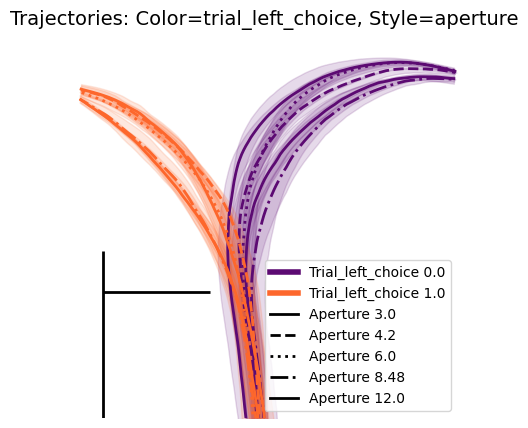

In [119]:
dfp = mean_trajectory_time(data [data.mouse_name == data.mouse_name.unique()[4]],
                                               index_columns= ["dataset", "mouse_name", "aperture", "trial_left_choice", "trial_length"])

dfp = mean_trajectory_time(dfp, index_columns= [ "mouse_name", "aperture", "trial_left_choice", "trial_length"])
plot_mean_trajectory_time(dfp, cmap = plotting.colors_choice)

In [108]:
big_df = pd.read_pickle("notebooks/Paper_figures/multi_occluder.pickle")
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})
big_df = big_df [big_df.iti == 0.0].copy()
j_shaped = analysis.get_jshaped_trials(big_df, threshold_duration=5, threshold_tortuosity=5).copy()
interpolated_j_shaped = utils.interpolate_j_shaped(
    j_shaped, box_df, n_points=100
)  # 100 to run anova
data = interpolated_j_shaped

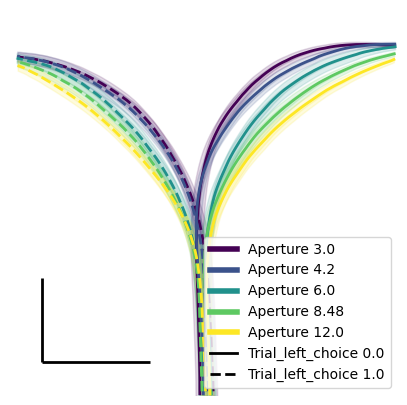

In [135]:
dfp = mean_trajectory_time(data, index_columns= ["dataset", "mouse_name", "aperture", "trial_left_choice", "trial_length"])

dfp = mean_trajectory_time(dfp, index_columns= ["aperture",  "trial_left_choice", "trial_length"])

plot_mean_trajectory_time(dfp, cmap = plt.cm.viridis, color_by="aperture", style_by="choice")
plt.savefig("multioccluder_trajectories_time.svg", transparent=True)